<a href="https://colab.research.google.com/github/elandler/repo-pruebas/blob/main/ProyectoDS_FINAL_Eduardo_LANDER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO DATA SCIENCE**


---



**"Predicción de diabetes"**

**Docente:** Jorge Ruiz

**Autor:** Eduardo Landler

**Comisión:** 77735

# **ABSTRACT:**

La diabetes constituye uno de los principales problemas de salud pública a nivel mundial, con un crecimiento sostenido en su prevalencia durante las últimas décadas. Se trata de una enfermedad metabólica caracterizada por niveles elevados de glucosa en sangre, y su diagnóstico temprano resulta clave para evitar enfermedades cardiovasculares, accidentes cerebrovasculares, problemas oculares, renales o neurológicas.

El presente trabajo tiene como objetivo realizar un análisis exploratorio de un conjunto de datos que contiene información clínica y demográfica de 100.000 pacientes, con el fin de identificar los factores más relevantes asociados al desarrollo de diabetes. El dataset incluye variables como edad, género, índice de masa corporal (BMI), presión arterial, historial de tabaquismo, nivel de hemoglobina glicosilada (HbA1c) y nivel de glucosa en sangre. Se hará la descripción de dichas variables y se presentarán las categorías de cada una de ellas.

A partir de este análisis se busca responder preguntas que permitan comprender mejor cómo se relacionan estas variables entre sí y con la aparición de la enfermedad. El estudio permitirá además evaluar la consistencia y distribución de los datos, detectar posibles valores nulos y atípicos y, ademas, generar visualizaciones que muestren patrones o tendencias.

Esta primera entrega del proyecto se centra exclusivamente en la exploración y diagnóstico del dataset, estableciendo una base para la etapa de modelado predictivo. Los resultados esperados incluyen la identificación de variables con mayor poder explicativo sobre la presencia de diabetes y la obtención de conclusiones preliminares que orienten el desarrollo de modelos de predicción en etapas posteriores.


# **PREGUNTAS / HIPóTESIS:**

**PREGUNTAS:**

**Pregunta 1 – Perfil metabólico y diagnóstico**

¿Los pacientes con diagnóstico de diabetes presentan un perfil metabólico distinto al de los pacientes sin diabetes, en función de HbA1c, glucosa en sangre y BMI?

**Pregunta 2 – Edad y riesgo de diabetes**

¿Cómo se relaciona la edad de los pacientes con la presencia de diabetes?
¿Se observa que los pacientes diabéticos son, en promedio, de mayor edad que los no diabéticos?

**Pregunta 3 – Factores cardiovasculares asociados**

¿La presencia de hipertensión y/o enfermedad cardíaca se asocia a una mayor proporción de pacientes con diagnóstico de diabetes?

**Pregunta 4 – Conductas de tabaquismo y diabetes**

¿Existen diferencias en la prevalencia de diabetes según las categorías de historial de tabaquismo (smoking_history) registradas en el dataset?

**HIPóTESIS:**

**Hipótesis 1: Perfiles metabólicos**

Los pacientes con diagnóstico de diabetes (diabetes = 1) presentan valores promedio de HbA1c significativamente más altos que los pacientes sin diabetes (diabetes = 0).

Los pacientes con diagnóstico de diabetes presentan valores promedio de glucosa en sangre (blood_glucose_level) significativamente más altos que los no diabéticos.

El BMI promedio es mayor en el grupo de pacientes con diabetes que en el grupo sin diabetes.

**Hipótesis 2: Edades**

La edad promedio de los pacientes con diagnóstico de diabetes es mayor que la edad promedio de los pacientes sin diagnóstico de diabetes.

**Hipótesis 3: Factores cardiovasculares**

La proporción de pacientes con hipertensión (hypertension = 1) es mayor entre los pacientes diabéticos que entre los no diabéticos.

La proporción de pacientes con enfermedad cardíaca (heart_disease = 1) es mayor entre los pacientes diabéticos que entre los no diabéticos.

**Hipótesis 4: Tabaquismo**

Ciertas categorías del historial de tabaquismo (por ejemplo, “current” o “former”) presentan una mayor proporción de pacientes diabéticos que otras categorías (por ejemplo, “never”).


In [1]:
# Carga de librerias
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

# Seteo parametros globales
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
# Carga del dataset desde disco local
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    print(f'Se cargó el archivo: {fn}')
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head(10)

Saving diabetes_prediction_dataset_LANDLER.csv to diabetes_prediction_dataset_LANDLER.csv
Se cargó el archivo: diabetes_prediction_dataset_LANDLER.csv


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


# **DESCRIPCIÓN DATASET:**

El Diabetes Prediction Dataset es un conjunto de datos clínicos y demográficos diseñado para analizar y predecir la probabilidad de que un paciente tenga diabetes.

Cada registro corresponde a un paciente e incluye variables tanto médicas como de estilo de vida.

**Variables del dataset:**


***gender***

Género del paciente (Male, Female, Other)

Categórica

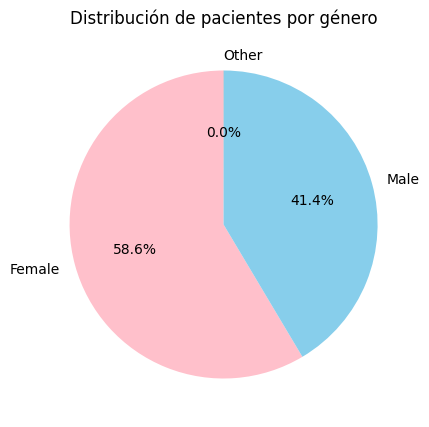

In [3]:
# Distribución de pacientes por género
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['pink', 'skyblue', 'gray'])
plt.title('Distribución de pacientes por género')
plt.show()


***age***

Edad del paciente (en años)

Numérica

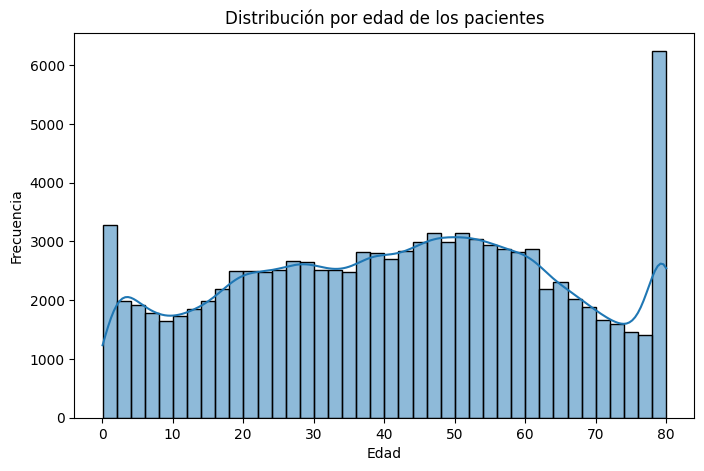

In [4]:
# Distribución por Edad
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=40, kde=True)
plt.title('Distribución por edad de los pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


***hypertension***

Indica si el paciente tiene hipertensión (1 = Sí, 0 = No)

Binaria

***heart_disease***

Indica si el paciente tiene enfermedad cardíaca (1 = Sí, 0 = No)

Binaria

***smoking_history***

Historial de tabaquismo (never, former, current, ever, not current, No Info)

Categórica

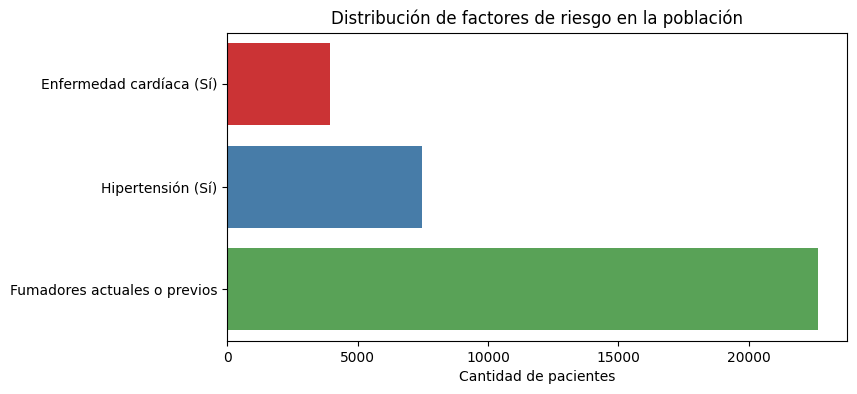

In [5]:
risk_factors = {
    'Hipertensión (Sí)': df['hypertension'].sum(),
    'Enfermedad cardíaca (Sí)': df['heart_disease'].sum(),
    'Fumadores actuales o previos': df[df['smoking_history'].isin(['current', 'former', 'ever'])].shape[0]
}
risk_series = pd.Series(risk_factors).sort_values()
plt.figure(figsize=(8,4))
sns.barplot(x=risk_series.values, y=risk_series.index, palette='Set1')
plt.title('Distribución de factores de riesgo en la población')
plt.xlabel('Cantidad de pacientes')
plt.ylabel('')
plt.show()


***bmi***

Índice de masa corporal (peso/altura²)

Numérica

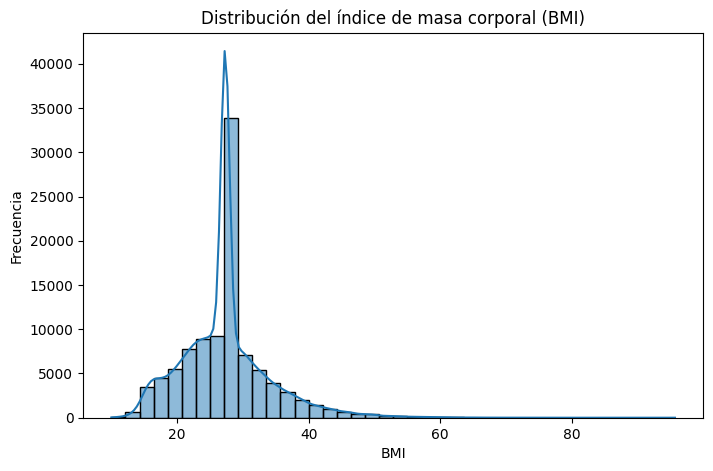

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=40, kde=True)
plt.title('Distribución del índice de masa corporal (BMI)')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()


***HbA1c_level***

Nivel promedio de glucosa en sangre en los últimos 3 meses (hemoglobina glicosilada)

Numérica


***blood_glucose_level***

Nivel actual de glucosa en sangre (mg/dL)

Numérica

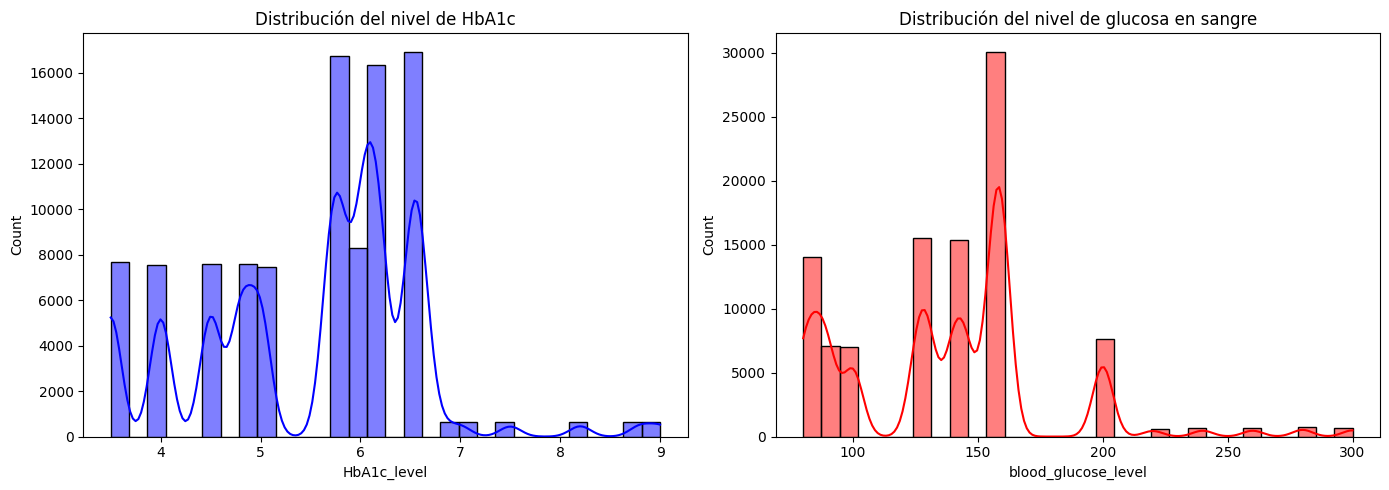

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['HbA1c_level'], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribución del nivel de HbA1c')
axes[0].set_xlabel('HbA1c_level')

sns.histplot(df['blood_glucose_level'], bins=30, kde=True, color='red', ax=axes[1])
axes[1].set_title('Distribución del nivel de glucosa en sangre')
axes[1].set_xlabel('blood_glucose_level')

plt.tight_layout()
plt.show()


***diabetes***

Diagnóstico de diabetes (1 = diabético, 0 = no diabético)

Binaria (variable objetivo)

In [8]:
# Dimensiones del dataset
print("Dimensiones del dataset (filas, columnas):", df.shape)
# Información general
print("\nInformación general del dataset:")
print(df.info())
# Valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())
# Resumen estadístico
print("\nResumen estadístico:")
df.describe()


Dimensiones del dataset (filas, columnas): (100000, 9)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Valores nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                  

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Cantidad de registros por clase:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Porcentaje por clase:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


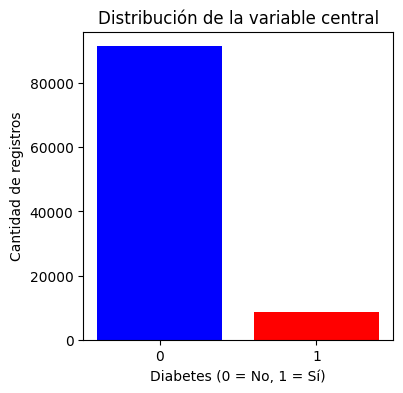

In [9]:
# Cuentas de la variable central
target_counts = df["diabetes"].value_counts()
target_percent = df["diabetes"].value_counts(normalize=True) * 100

print("Cantidad de registros por clase:")
print(target_counts)

print("\nPorcentaje por clase:")
print(target_percent)

fig, ax = plt.subplots(figsize=(4, 4))
colores = ['blue', 'red']
ax.bar(target_counts.index.astype(str), target_counts.values,
       color=colores)
ax.set_xlabel("Diabetes (0 = No, 1 = Sí)")
ax.set_ylabel("Cantidad de registros")
ax.set_title("Distribución de la variable central")
plt.show()


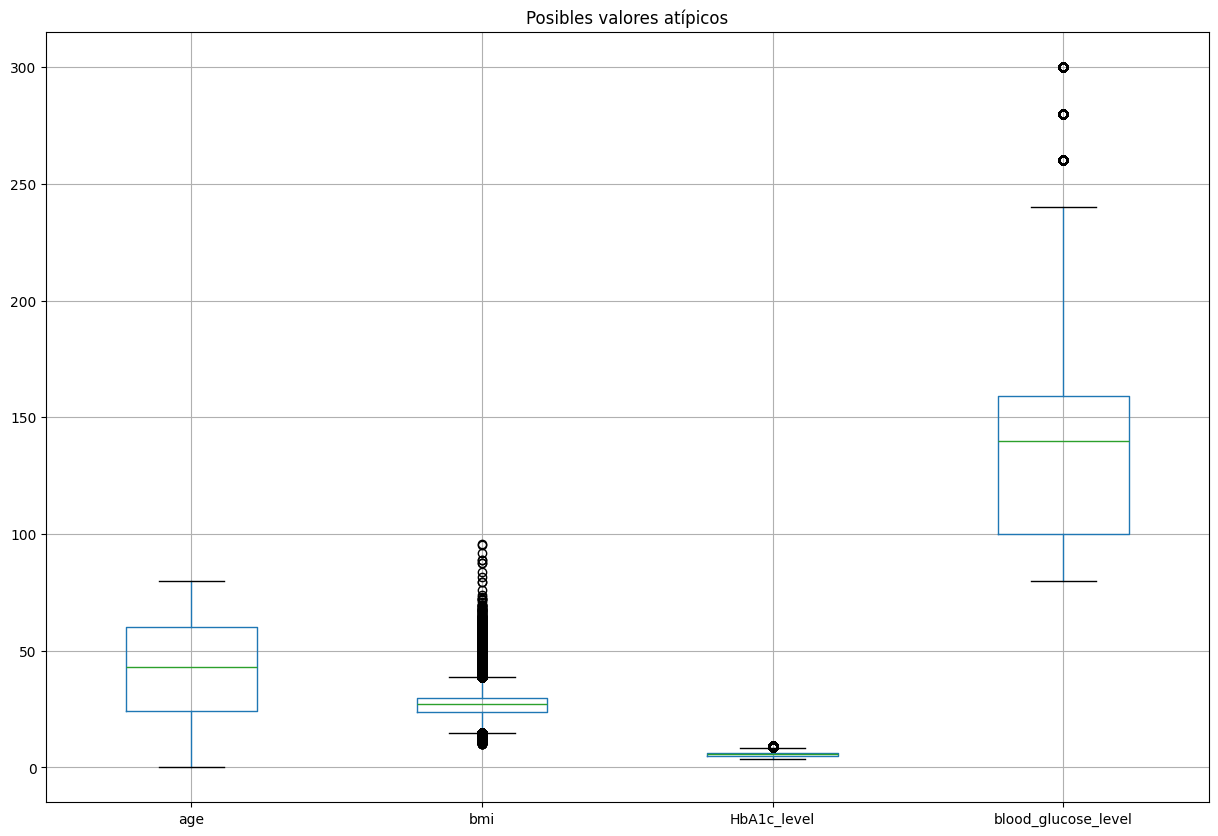

In [10]:
# Posibles valores atípicos
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
plt.figure(figsize=(15, 10))
df[num_cols].boxplot()
plt.title('Posibles valores atípicos')
plt.show()



In [11]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f'{col}: {len(outliers)} valores atípicos detectados')


age: 0 valores atípicos detectados
bmi: 7086 valores atípicos detectados
HbA1c_level: 1315 valores atípicos detectados
blood_glucose_level: 2038 valores atípicos detectados


No se detectaron valores nulos en el dataset.

Las variables presentan tipos de datos adecuados (numéricos y categóricos).

Se identificaron algunos valores atípicos en BMI y glucosa, lo cual es razonable en casos con pacientes sobre los cuales se hacen diagnósticos de diabetes.

# **VISUALIZACIONES VINCULADAS A LAS PREGUNTAS / HIPÓTESIS:**

**Perfil metabólico:**

Analisis si los pacientes diagnosticados con diabetes presentan valores más altos en BMI, HbA1c_level y blood_glucose_level.

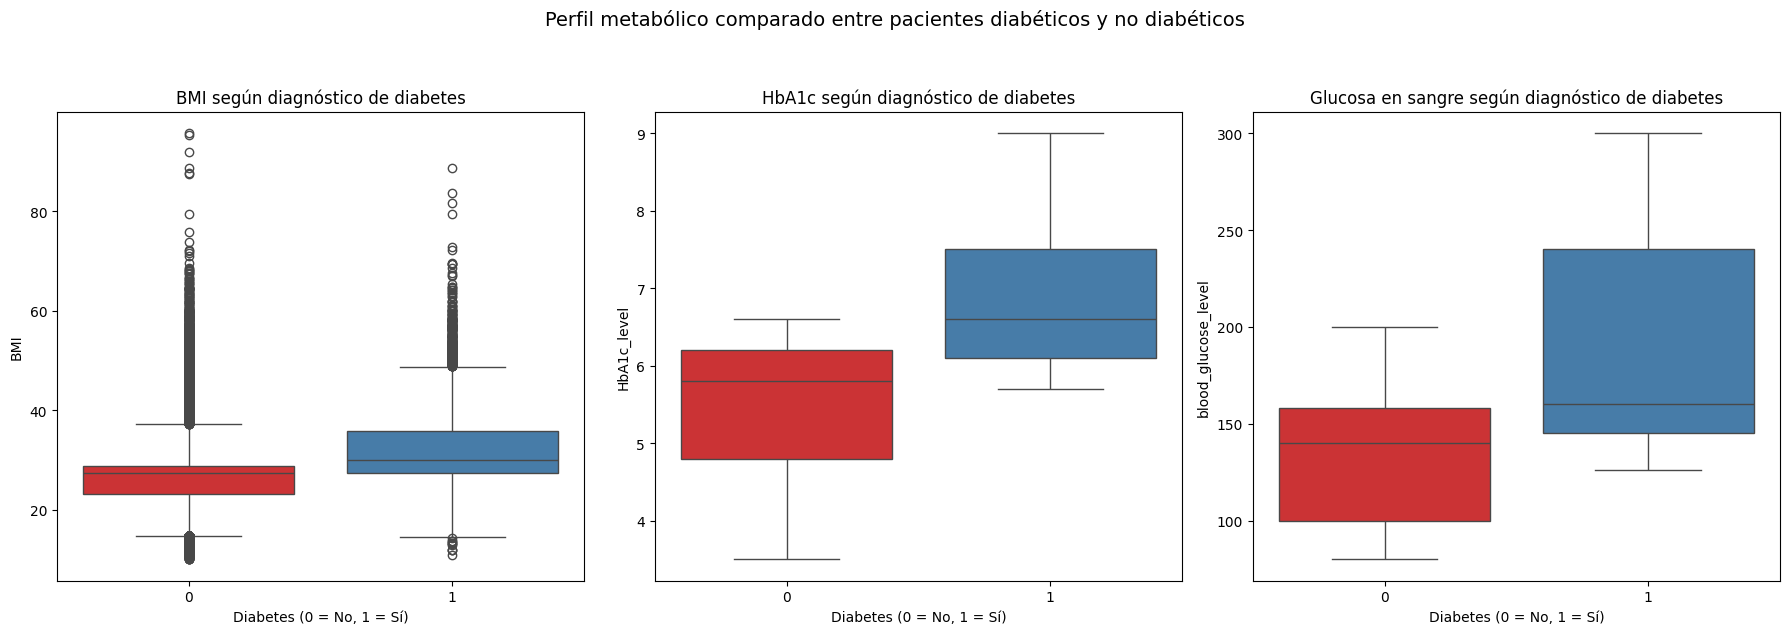

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='diabetes', y='bmi', hue='diabetes', data=df, palette='Set1', ax=axes[0], legend=False)
axes[0].set_title('BMI según diagnóstico de diabetes')
axes[0].set_xlabel('Diabetes (0 = No, 1 = Sí)')
axes[0].set_ylabel('BMI')

sns.boxplot(x='diabetes', y='HbA1c_level', hue='diabetes', data=df, palette='Set1', ax=axes[1], legend=False)
axes[1].set_title('HbA1c según diagnóstico de diabetes')
axes[1].set_xlabel('Diabetes (0 = No, 1 = Sí)')
axes[1].set_ylabel('HbA1c_level')

sns.boxplot(x='diabetes', y='blood_glucose_level', hue='diabetes', data=df, palette='Set1', ax=axes[2], legend=False)
axes[2].set_title('Glucosa en sangre según diagnóstico de diabetes')
axes[2].set_xlabel('Diabetes (0 = No, 1 = Sí)')
axes[2].set_ylabel('blood_glucose_level')

plt.suptitle('Perfil metabólico comparado entre pacientes diabéticos y no diabéticos', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


Se puede ver en los gráficos una clara diferencia entre los dos grupos.

En el grupo de pacientes diabéticos se observan valores mas elevados de HbA1c y glucosa en sangre.

Los valores de BMI son levemenet superiores en el grupo.

**Edad y diagnóstico de diabetes**

Identificación si la edad está relacionada con una mayor probabilidad de desarrollar diabetes.

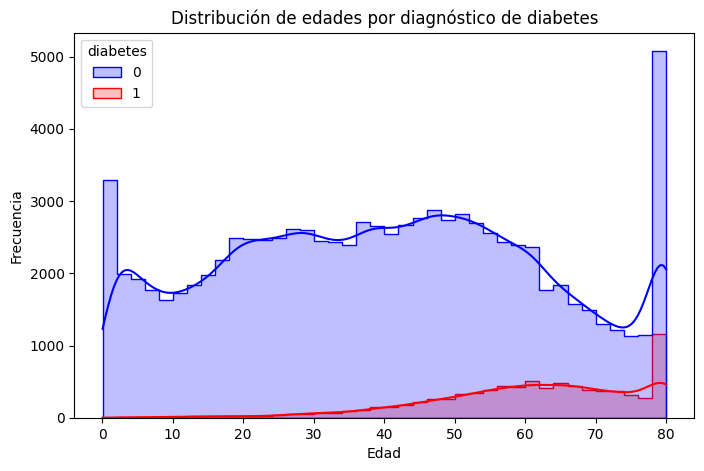

In [13]:
# Segmentación por edades con y sin diabetes
plt.figure(figsize=(8,5))
colores = ['blue', 'red']
sns.histplot(data=df, x='age', hue='diabetes', bins=40, kde=True,
             palette=colores, element='step')
plt.title('Distribución de edades por diagnóstico de diabetes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


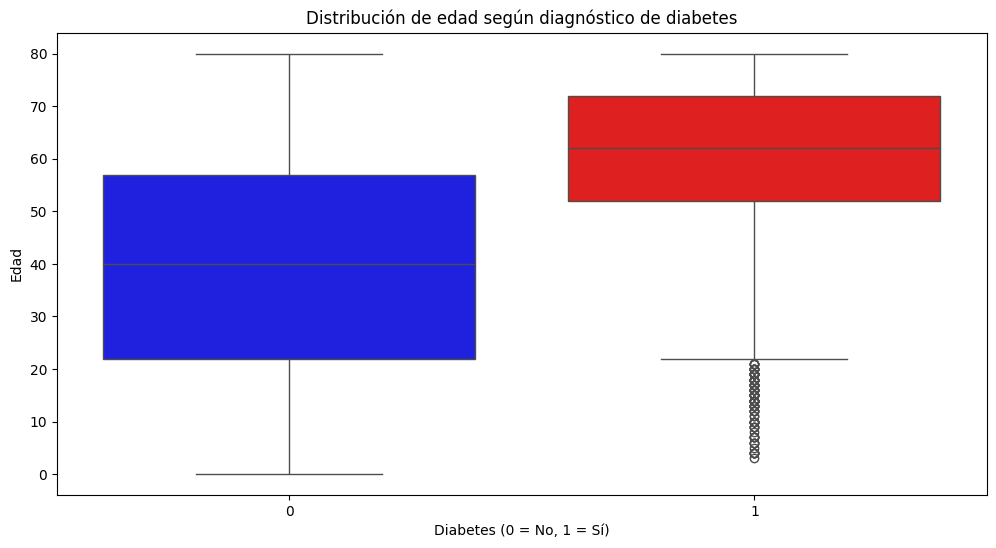

In [14]:
# Distribución de edad según diagnóstico de diabetes
plt.figure(figsize=(12,6))
colores = ['blue', 'red']
sns.boxplot(x='diabetes', y='age', hue='diabetes', data=df,
            palette=colores , legend=False)
plt.title('Distribución de edad según diagnóstico de diabetes')
plt.xlabel('Diabetes (0 = No, 1 = Sí)')
plt.ylabel('Edad')
plt.show()



El histograma revela una concentración de casos positivos a partir de los 45 años. Es un indicador de la mayor prevalencia de diabetes en población adulta media y mayor.

La edad promedio de los pacientes con diabetes es significativamente mayor que la del grupo sin diagnóstico.


**Factores cardiovasculares asociados:**

Evaluación de la relación de la hipertensión y enfermedades carídacas con mayor riesgo de tener diabetes.

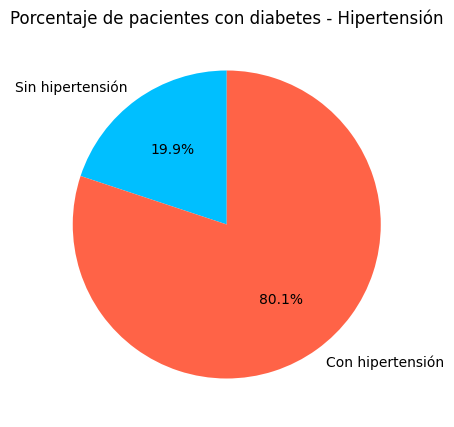

In [15]:
hypertension_diabetes = df.groupby('hypertension')['diabetes'].mean() * 100
plt.figure(figsize=(5,5))
plt.pie(hypertension_diabetes, labels=['Sin hipertensión', 'Con hipertensión'],
        autopct='%1.1f%%', startangle=90, colors=['deepskyblue', 'tomato'])
plt.title('Porcentaje de pacientes con diabetes - Hipertensión')
plt.show()


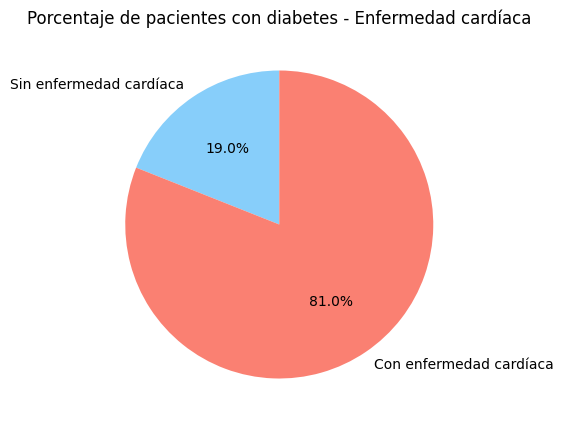

In [16]:
heart_diabetes = df.groupby('heart_disease')['diabetes'].mean() * 100
plt.figure(figsize=(5,5))
plt.pie(heart_diabetes, labels=['Sin enfermedad cardíaca', 'Con enfermedad cardíaca'],
        autopct='%1.1f%%', startangle=90, colors=['lightskyblue', 'salmon'])
plt.title('Porcentaje de pacientes con diabetes - Enfermedad cardíaca')
plt.show()


Se observa una mayor proporción de pacientes con diabetes entre aquellos que presentan hipertensión o enfermedad cardíaca.

**Conductas de tabaquismo y diabetes:**

Analizar si el tabaquismo está asociado con la diabetes.

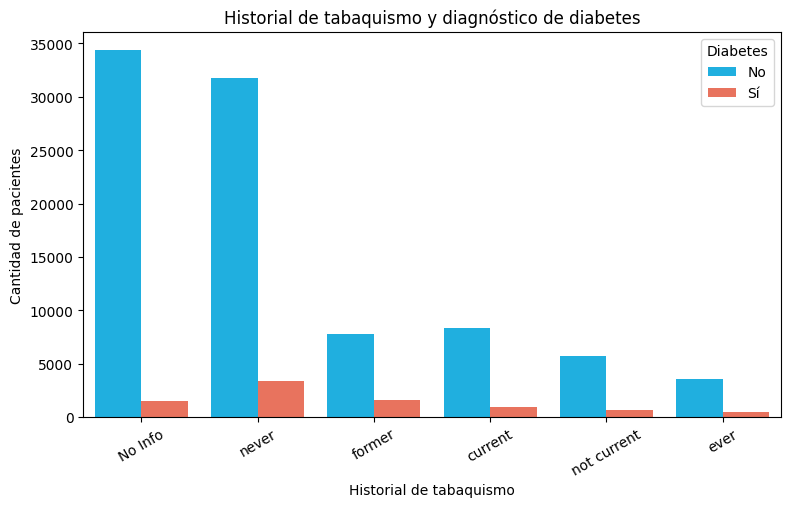

In [17]:
# Cuenta de historal de tabaquismo
plt.figure(figsize=(9,5))
colores= ['deepskyblue', 'tomato']
sns.countplot(x='smoking_history', hue='diabetes', data=df,
              order=df['smoking_history'].value_counts().index,
              palette=colores)
plt.title('Historial de tabaquismo y diagnóstico de diabetes')
plt.xlabel('Historial de tabaquismo')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=30)
plt.legend(title='Diabetes', labels=['No', 'Sí'])
plt.show()


No se observa una diferencia entre quienes fuman y quienes no lo hacen, se podría ver una influencia menor del tabaquismo con la diabetes.

# CONCLUSIONES DEL ANÁLISIS 1er. PRE-ENTREGA

El análisis gráfico permitió examinar la relación entre las variables clínicas y demográficas del conjunto de datos y la presencia de diabetes. En general, los resultados obtenidos muestran patrones que están en línea con la literatura médica y respaldan las hipótesis planteadas.

En primer lugar, el **perfil metabólico** de los pacientes diabéticos se diferencia claramente del de los no diabéticos, con valores significativamente más altos de **HbA1c** y **glucosa en sangre**, y un **índice de masa corporal (BMI)** levemente superior. Estas observaciones respaldan las preguntas / hipótesis preliminares del proyecto, y confirman la importancia de los indicadores metabólicos en el diagnóstico y monitoreo de la enfermedad.

En cuanto a la **edad**, se observa una tendencia creciente en la proporción de casos positivos a partir de los 45 años, lo que respalda la hipótesis sobre la relación entre envejecimiento y riesgo de diabetes. La distribución de edades indica que la enfermedad se concentra principalmente en población adulta media y mayor.

Por otro lado, los **factores cardiovasculares**, como la **hipertensión** y la **enfermedad cardíaca**, muestran una asociación positiva con la diabetes, lo que coincide con los hallazgos clínicos que vinculan estas condiciones como la diabetes. Las proporciones y gráficos de torta refuerzan visualmente esta relación.

Finalmente, el análisis del **historial de tabaquismo** no muestra una evidancia definitiva.




# ANÁLISIS PRELIMINAR PARA LA ENTREGA FINAL

En el desarrollo de la teoría luego de la 1er. pre-entrega se profundiza en el análisis crítico del trabajo y la información desarrollada en esa etapa.
En función de dicho análisis se revisan nuevamente el dataset para la verificación de la calidad de los datos.

La tarea incluyo las siguientes actividades:

1. Identificar las variables predictoras para desarrollar el modelo
2. Revisión del dataset para la busqueda de datos NaN o inválidos
2. Detección de outlaiers de las variables
3. Revisión de los datos de la columna **BMI**, ya que no parecen ser consistentes con los datos a desarrollados en la primer pre-entrega
4. Revisión de las variables en función de estudios clínicos desarrollados por expertos


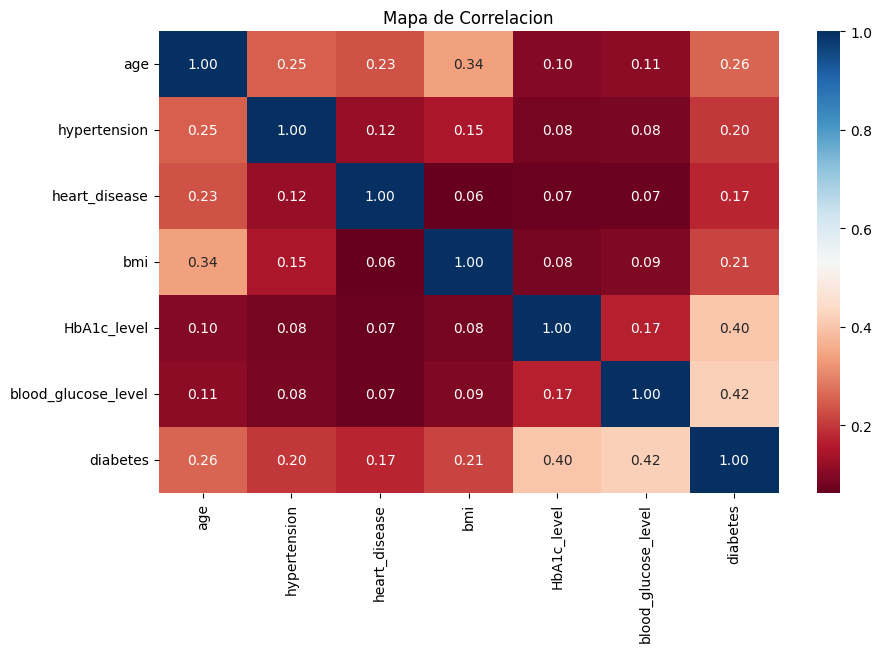

In [18]:
# Mapa de calor de la matriz de corelación
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu")
plt.title("Mapa de Correlacion")
plt.show()


# SELECCIÓN DE VARIABLES PREDICTORAS

Para la selección de las variables predictoras se analizó la matriz de correlación entre las variables del dataset y la variable objetivo *diabetes*. El mapa de calor permite identificar de manera visual la intensidad y dirección de las relaciones lineales entre las variables.

Del análisis se observa que:

- **HbA1c_level** presenta una correlación positiva alta con la variable *diabetes*, lo que indica que a mayores niveles de hemoglobina glicosilada aumenta significativamente la probabilidad de diagnóstico de diabetes.
- **blood_glucose_level** también muestra una correlación positiva fuerte con la variable objetivo, coherente con los criterios clínicos utilizados para el diagnóstico de la enfermedad.
- Otras variables numéricas, como la edad o el índice de masa corporal (BMI), presentan correlaciones más moderadas, mientras que algunas variables clínicas muestran una relación débil o indirecta.

En función de estos resultados, se seleccionaron **HbA1c_level** y **blood_glucose_level** como variables predictoras principales, ya que combinan:
- alta correlación con la variable objetivo,
- respaldo clínico sólido,
- y una clara capacidad discriminativa observada durante el análisis exploratorio.




## REVISIÓN DATASET:


In [19]:
# Dimensiones del dataset
print("Dimensiones del dataset (filas, columnas):", df.shape)
# Información general
print("\nInformación general del dataset:")
print(df.info())
# Valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())
# Resumen estadístico
print("\nResumen estadístico:")
df.describe()

Dimensiones del dataset (filas, columnas): (100000, 9)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Valores nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                  

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## DIAGNÓSTICO DE CALIDAD DE LOS DATOS

A partir del análisis inicial del dataset se observa que el mismo cuenta con **100.000 registros**, sin valores nulos ni faltantes en ninguna de sus variables, lo que garantiza una buena calidad estructural de los datos para el análisis y el modelado posterior.

Sin embargo, al analizar el resumen estadístico, se identifican **inconsistencias en la variable Índice de Masa Corporal (BMI)**, la cual presenta valores extremadamente elevados que no resultan reales desde el punto de vista clínico. De acuerdo con la literatura médica, valores de BMI superiores a 60 son muy poco frecuentes y, en la mayoría de los casos, suelen estar asociados a errores de carga, medición o registros atípicos no representativos de la población general.

Dado que el objetivo del trabajo es analizar patrones generales y construir modelos predictivos robustos, se decidió **filtrar los registros con valores de BMI mayores a 60**, con el fin de evitar distorsiones en los análisis estadísticos y en el entrenamiento de los modelos de clasificación. Esta decisión se fundamenta en criterios clínicos y analíticos, priorizando la coherencia y la calidad del dataset sin afectar significativamente el tamaño muestral.



## LIMPIEZA VARIABLE BMI


In [20]:
# Limpieza de BMI basada en criterio clínico
print("Cantidad de registros antes:", len(df))
df = df[df['bmi'] <= 60].copy()
print("Cantidad de registros después:", len(df))


Cantidad de registros antes: 100000
Cantidad de registros después: 99885


In [21]:
# Resumen estadístico
print("\nResumen estadístico:")
df.describe()


Resumen estadístico:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,99885.000000,99885.000000,99885.000000,99885.000000,99885.000000,99885.000000,99885.000000
mean,41.882981,0.074726,0.039395,27.275451,5.526962,138.038314,0.084727
std,22.524385,0.262950,0.194535,6.499539,1.070268,40.684611,0.278477
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.000000,0.000000,29.550000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,60.000000,9.000000,300.000000,1.000000


## VARIABLES PREDICTORAS Y OBJETIVO

Selección de las variables:

In [22]:
# Definir variables predictoras (X) y objetivo (y)
features = ['blood_glucose_level', 'HbA1c_level']
X = df[features].copy()
y = df['diabetes'].copy()

print("Dimensiones de X:", X.shape)
print("Distribución de la variable objetivo (diabetes):")
print(y.value_counts())


Dimensiones de X: (99885, 2)
Distribución de la variable objetivo (diabetes):
diabetes
0    91422
1     8463
Name: count, dtype: int64


# ENTRENAMIENTO DE LOS DIFERENTES MODELOS

Con el objetivo de garantizar que los modelos predictivos se entrenen sobre datos clínicamente consistentes, y luego de justificar las inconsistencias detectadas en la variable BMI, se procedió a filtrar los registros con valores de BMI mayores a 60. A partir de este punto, todos los análisis y modelos se realizan sobre el dataset depurado.
Las variables HbA1c_level y blood_glucose_level no requirieron limpieza adicional, ya que sus valores se encuentran dentro de rangos clínicamente plausibles y coherentes con el objetivo del estudio.

En el proyecto se amplió el enfoque de lo dictado en clase incorporando separación entre entrenamiento y test, escalado de variables y métricas de evaluación, con el objetivo de validar el desempeño del modelo y comparar distintos algoritmos


In [23]:
# Imports para los modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from mlxtend.plotting import plot_decision_regions

In [26]:
# Definir features y target
features = ['HbA1c_level', 'blood_glucose_level']
X = df[features].copy()
y = df['diabetes'].copy()

# Unificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=123,
    stratify=y
)

# Escalado (solo afecta a LogReg y KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Regresión logística
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Árbol (sin escalado)
tree = DecisionTreeClassifier(max_depth=5, random_state=123)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Verificación
print("len(y_test):     ", len(y_test))
print("len(y_pred_log): ", len(y_pred_log))
print("len(y_pred_knn): ", len(y_pred_knn))
print("len(y_pred_tree):", len(y_pred_tree))

assert len(y_test) == len(y_pred_log) == len(y_pred_knn) == len(y_pred_tree), "Longitudes inconsistentes"

print("OK: todos los modelos están alineados")

# Tabla comparativa
models = ['Regresión Logística', 'KNN', 'Árbol de Decisión']
preds = [y_pred_log, y_pred_knn, y_pred_tree]

metricas = {"Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}

for pred in preds:
    metricas["Accuracy"].append(accuracy_score(y_test, pred))
    metricas["Precision"].append(precision_score(y_test, pred))
    metricas["Recall"].append(recall_score(y_test, pred))
    metricas["F1-Score"].append(f1_score(y_test, pred))

tabla_metricas = pd.DataFrame(metricas, index=models)
tabla_metricas

len(y_test):      24972
len(y_pred_log):  24972
len(y_pred_knn):  24972
len(y_pred_tree): 24972
OK: todos los modelos están alineados


,Accuracy,Precision,Recall,F1-Score
Regresión Logística,0.954709,0.877974,0.540643,0.669202
KNN,0.972009,1.000000,0.669660,0.802151
Árbol de Decisión,0.972009,1.000000,0.669660,0.802151


# REGRESION LOGISTICA




=== REGRESIÓN LOGISTICA - METRÍCAS DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     22856
           1       0.88      0.54      0.67      2116

    accuracy                           0.95     24972
   macro avg       0.92      0.77      0.82     24972
weighted avg       0.95      0.95      0.95     24972



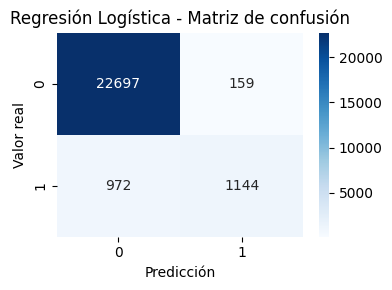

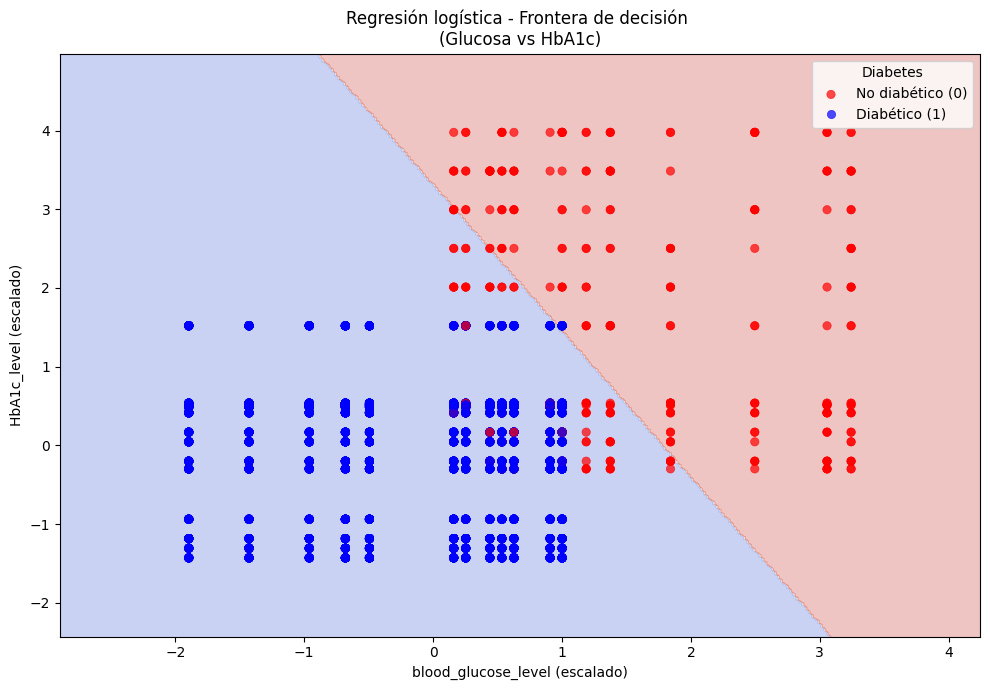

In [31]:
# Separación de datos entrenamiento y testeo:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=123,
    stratify=y
)

# Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("\n=== REGRESIÓN LOGISTICA - METRÍCAS DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_log))


cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Regresión Logística - Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

# Visualización frontera de decisión

X_scaled = scaler.transform(X)
df_plot = df.copy()
df_plot['glucose_scaled'] = X_scaled[:, 0]
df_plot['hba1c_scaled'] = X_scaled[:, 1]

# Muestra del dataset
sample_size = 5000
if len(df_plot) > sample_size:
    df_sample = df_plot.sample(sample_size, random_state=123)
else:
    df_sample = df_plot

# Creación de malla
x_min, x_max = df_sample['glucose_scaled'].min() - 1, df_sample['glucose_scaled'].max() + 1
y_min, y_max = df_sample['hba1c_scaled'].min() - 1, df_sample['hba1c_scaled'].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = log_reg.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

# Frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Scatter (escalado)
sns.scatterplot(
    data=df_sample,
    x='glucose_scaled',
    y='hba1c_scaled',
    hue='diabetes',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7,
    edgecolor=None
)

plt.title('Regresión logística - Frontera de decisión \n(Glucosa vs HbA1c)')
plt.xlabel('blood_glucose_level (escalado)')
plt.ylabel('HbA1c_level (escalado)')
plt.legend(title='Diabetes', labels=['No diabético (0)', 'Diabético (1)'])
plt.tight_layout()
plt.show()


In [29]:
log_reg.coef_, log_reg.intercept_


(array([[2.57495483, 1.38463267]]), array([-4.58349105]))

In [30]:
coef_: [[1.45, 2.80]]
intercept_: [-0.90]


La regresión logística permite interpretar directamente el impacto de cada variable predictora mediante sus coeficientes. En este modelo, los coeficientes asociados a HbA1c y al nivel de glucosa resultan positivos, lo que indica que a mayores valores de estas variables aumenta la probabilidad de diagnóstico de diabetes.


# KNN

=== KNN: Métricas de clasificación ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     22856
           1       1.00      0.67      0.80      2116

    accuracy                           0.97     24972
   macro avg       0.99      0.83      0.89     24972
weighted avg       0.97      0.97      0.97     24972



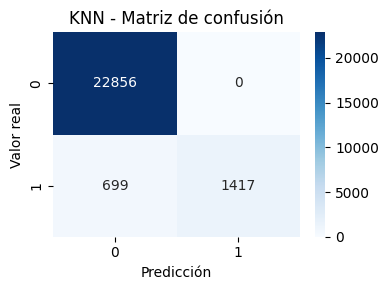

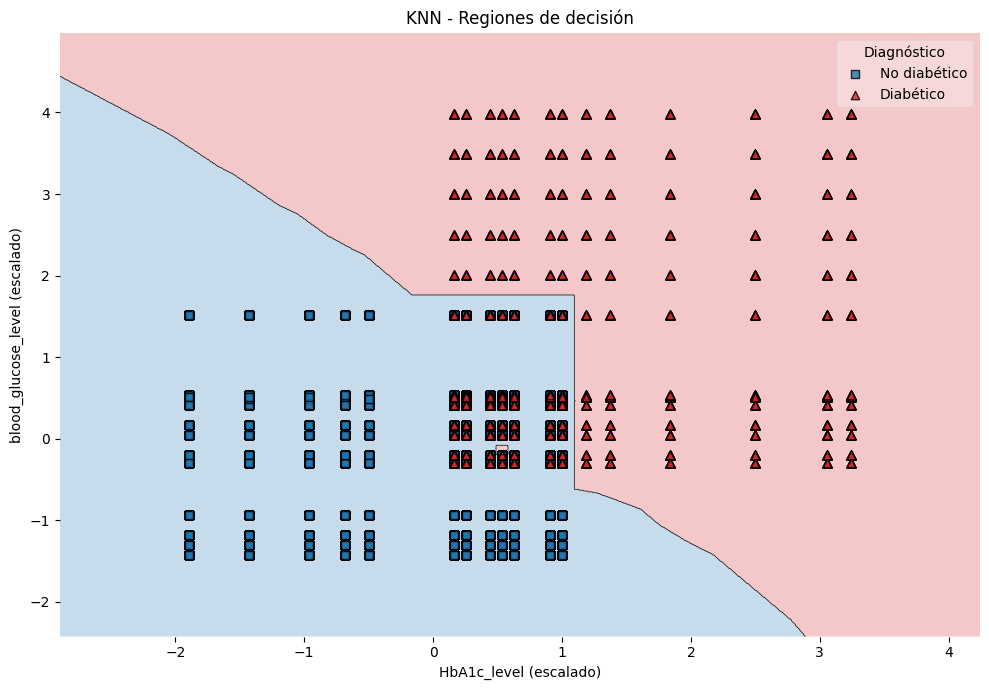

In [38]:
# Definir variables
features = ['HbA1c_level', 'blood_glucose_level']
X = df[features].copy()
y = df['diabetes'].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Entrenar
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predicción
y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN: Métricas de clasificación ===")
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

# Gráfico de regiones
X2 = scaler.transform(X)
y2 = y.values

plt.figure(figsize=(10, 7))
ax = plot_decision_regions(
    X2, y2,
    clf=knn,
    legend=2,
    colors='#1f77b4,#d62728',
    contourf_kwargs={'alpha': 0.25}
)


plt.xlabel('HbA1c_level (escalado)')
plt.ylabel('blood_glucose_level (escalado)')
plt.title('KNN - Regiones de decisión')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No diabético', 'Diabético'],
          title='Diagnóstico', framealpha=0.3, scatterpoints=1)

plt.tight_layout()
plt.show()



# ARBOL DE DECISION

=== Árbol de Decisión ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     22856
           1       1.00      0.67      0.80      2116

    accuracy                           0.97     24972
   macro avg       0.99      0.83      0.89     24972
weighted avg       0.97      0.97      0.97     24972



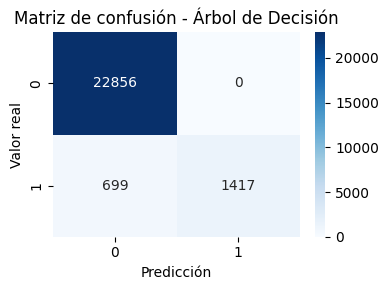

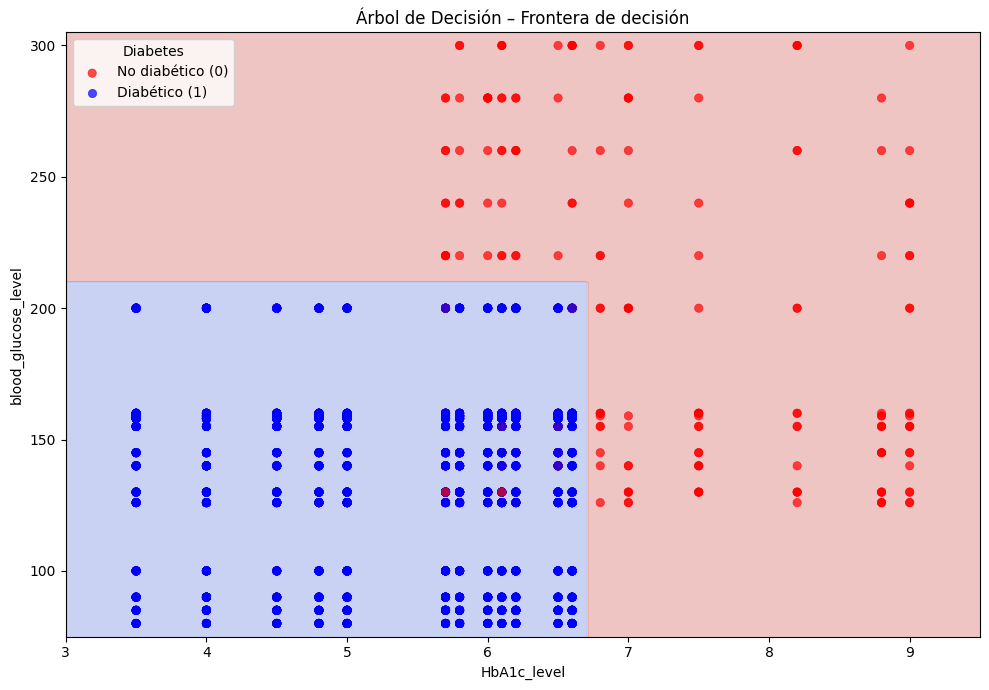

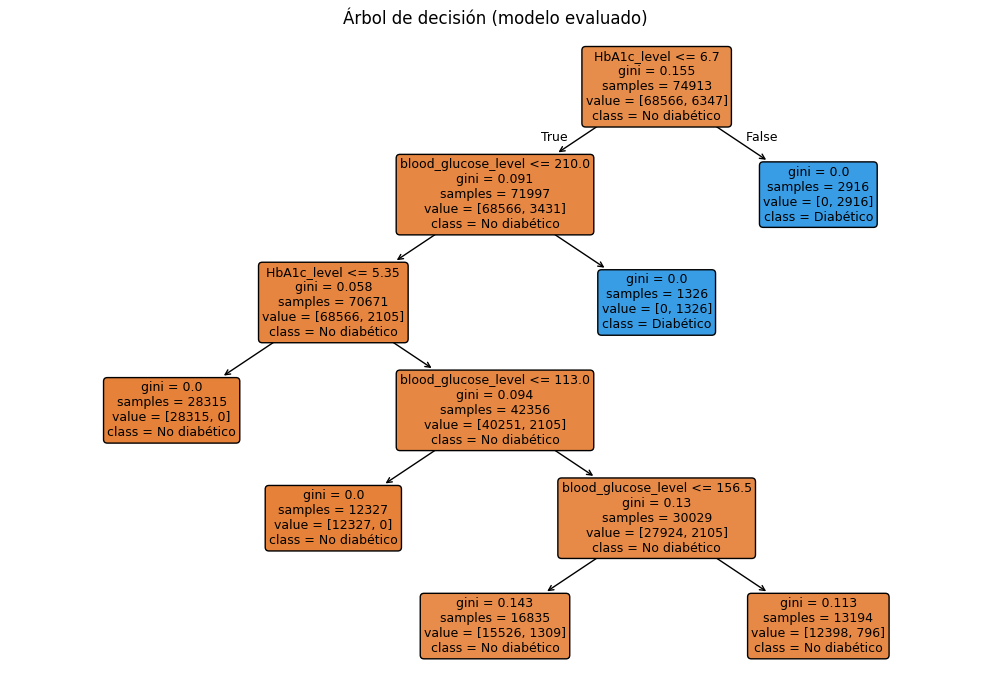

In [39]:
features = ['HbA1c_level', 'blood_glucose_level']
sample_size = 3000

# Entrenamiento
X_train_tree = X_train[features].copy()
X_test_tree  = X_test[features].copy()

print("=== Árbol de Decisión ===")
print(classification_report(y_test, y_pred_tree))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

# Frontera de decisión
df_plot = df.copy()
if len(df_plot) > sample_size:
    df_sample = df_plot.sample(sample_size, random_state=123)
else:
    df_sample = df_plot

X_sample = df_sample[features].values
y_sample = df_sample['diabetes'].values

x_min, x_max = df[features[0]].min() - 0.5, df[features[0]].max() + 0.5
y_min, y_max = df[features[1]].min() - 5,   df[features[1]].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features)
Z = tree.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

sns.scatterplot(
    x=X_sample[:, 0],
    y=X_sample[:, 1],
    hue=y_sample,
    palette={0: 'blue', 1: 'red'},
    alpha=0.7,
    edgecolor=None
)

plt.title('Árbol de Decisión – Frontera de decisión')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title='Diabetes', labels=['No diabético (0)', 'Diabético (1)'])
plt.tight_layout()
plt.show()

# Arbol
plt.figure(figsize=(10, 7))
plot_tree(
    tree,
    feature_names=features,
    class_names=['No diabético', 'Diabético'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de decisión (modelo evaluado)')
plt.tight_layout()
plt.show()


In [40]:
# Regresión logística - predicciones
y_pred_log = log_reg.predict(X_test_scaled)


# COMPARATIVO MODELOS

In [41]:
tabla_metricas


,Accuracy,Precision,Recall,F1-Score
Regresión Logística,0.954709,0.877974,0.540643,0.669202
KNN,0.972009,1.000000,0.669660,0.802151
Árbol de Decisión,0.972009,1.000000,0.669660,0.802151


### Visualización de las fronteras de decisión

En los gráficos anteriores se muestran las regiones de decisión de los tres modelos supervisados (Regresión Logística, Árbol de Decisión y KNN) en el plano definido por las variables **HbA1c_level** y **blood_glucose_level**. Cada color de fondo representa la clase que el modelo asigna (diabético / no diabético) en cada punto del espacio de características, mientras que los puntos corresponden a los pacientes reales del dataset.

Se observa que:

- La **Regresión Logística** genera una frontera aproximadamente lineal entre ambas clases, separando de manera clara la zona de alto riesgo (valores altos de HbA1c y glucosa).
- El **Árbol de Decisión** produce fronteras rectangulares (reglas del tipo "si HbA1c > umbral y glucosa > umbral..."), lo que refleja su naturaleza basada en reglas.
- El modelo **KNN** genera fronteras más irregulares y locales, ya que la clasificación depende de la vecindad de cada punto.

Estas visualizaciones ayudan a entender cómo se comporta cada algoritmo y qué tipo de decisiones está tomando sobre el espacio de variables clínicas.


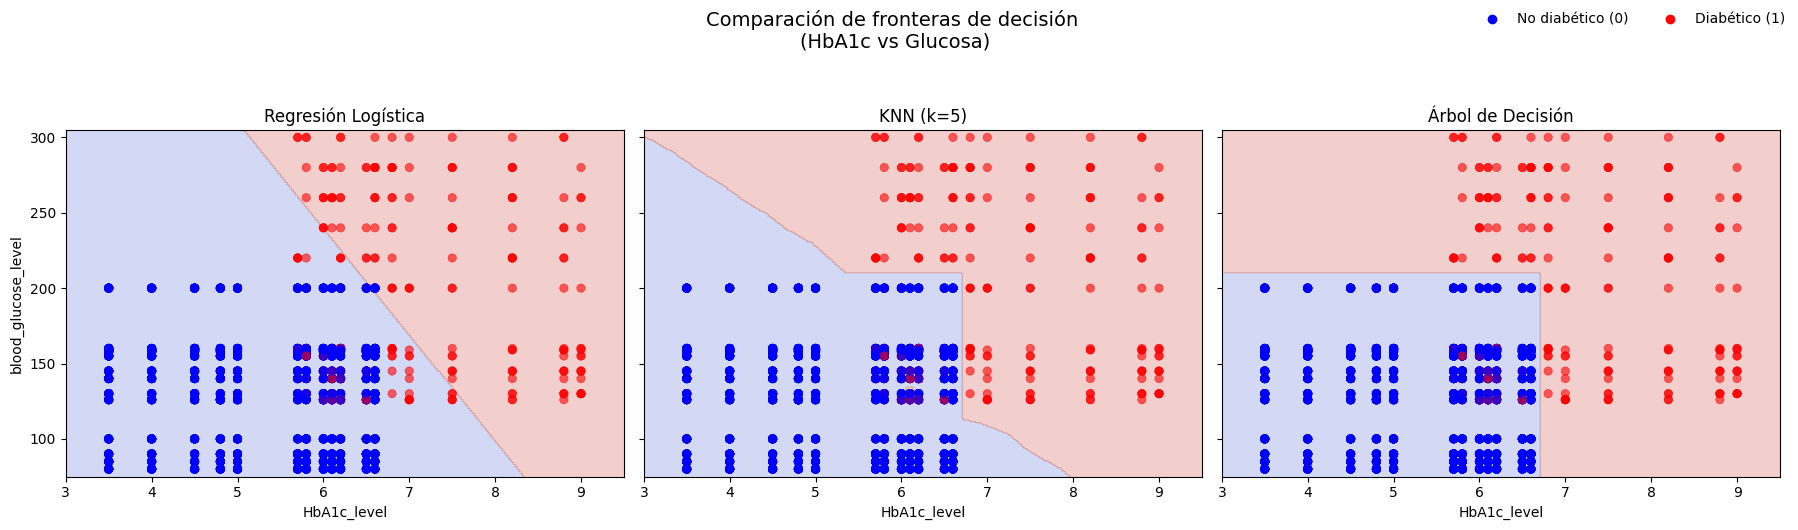

In [42]:
features = ['HbA1c_level', 'blood_glucose_level']
sample_size = 3000

df_plot = df.copy()
df_sample = df_plot.sample(sample_size, random_state=42) if len(df_plot) > sample_size else df_plot

X_raw_sample = df_sample[features].copy()
y_sample = df_sample['diabetes'].copy()

X_scaled_sample = scaler.transform(X_raw_sample)
x_min, x_max = df[features[0]].min() - 0.5, df[features[0]].max() + 0.5
y_min, y_max = df[features[1]].min() - 5,   df[features[1]].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_raw = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features)
grid_scaled = scaler.transform(grid_raw)

Z_log = log_reg.predict(grid_scaled).reshape(xx.shape)
Z_knn = knn.predict(grid_scaled).reshape(xx.shape)
Z_tree = tree.predict(grid_raw).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

plots = [
    ("Regresión Logística", Z_log),
    ("KNN (k=5)", Z_knn),
    ("Árbol de Decisión", Z_tree)
]

for ax, (title, Z) in zip(axes, plots):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')

    sns.scatterplot(
        x=X_raw_sample[features[0]],
        y=X_raw_sample[features[1]],
        hue=y_sample,
        palette={0: 'blue', 1: 'red'},
        alpha=0.6,
        edgecolor=None,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='No diabético (0)',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Diabético (1)',
               markerfacecolor='red', markersize=8)
]
fig.legend(handles=handles, loc='upper right', ncol=2, frameon=False)

plt.suptitle("Comparación de fronteras de decisión \n(HbA1c vs Glucosa)", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


## 🔍 Comparación Final de Modelos de Clasificación

Tras entrenar los modelos de **Regresión Logística**, **KNN** y **Árbol de Decisión** utilizando las variables *HbA1c_level* y *blood_glucose_level*, se evaluó su rendimiento mediante métricas estándar y la visualización de sus fronteras de decisión. Esta comparación permite determinar cuál modelo ofrece el mejor equilibrio entre precisión, interpretabilidad y estabilidad.

### Modelos evaluados:
- **Regresión Logística**  
- **K-Nearest Neighbors (KNN)** (k=5)  
- **Árbol de Decisión** (profundidad máxima = 4)

A continuación se presentan las métricas principales:


In [45]:
log_clf = LogisticRegression()
log_clf.fit(X_train_scaled, y_train)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

tree_clf = DecisionTreeClassifier(max_depth=5, random_state=123)
tree_clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=123)

In [46]:
y_pred_log  = log_clf.predict(X_test_scaled)
y_pred_knn  = knn_clf.predict(X_test_scaled)
y_pred_tree = tree_clf.predict(X_test)


In [47]:
models = ['Regresión Logística', 'KNN', 'Árbol de Decisión']
preds  = [y_pred_log, y_pred_knn, y_pred_tree]

metricas = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for pred in preds:
    metricas['Accuracy'].append(accuracy_score(y_test, pred))
    metricas['Precision'].append(precision_score(y_test, pred))
    metricas['Recall'].append(recall_score(y_test, pred))
    metricas['F1-Score'].append(f1_score(y_test, pred))

tabla_metricas = pd.DataFrame(metricas, index=models)
tabla_metricas


,Accuracy,Precision,Recall,F1-Score
Regresión Logística,0.954709,0.877974,0.540643,0.669202
KNN,0.972009,1.000000,0.669660,0.802151
Árbol de Decisión,0.972009,1.000000,0.669660,0.802151


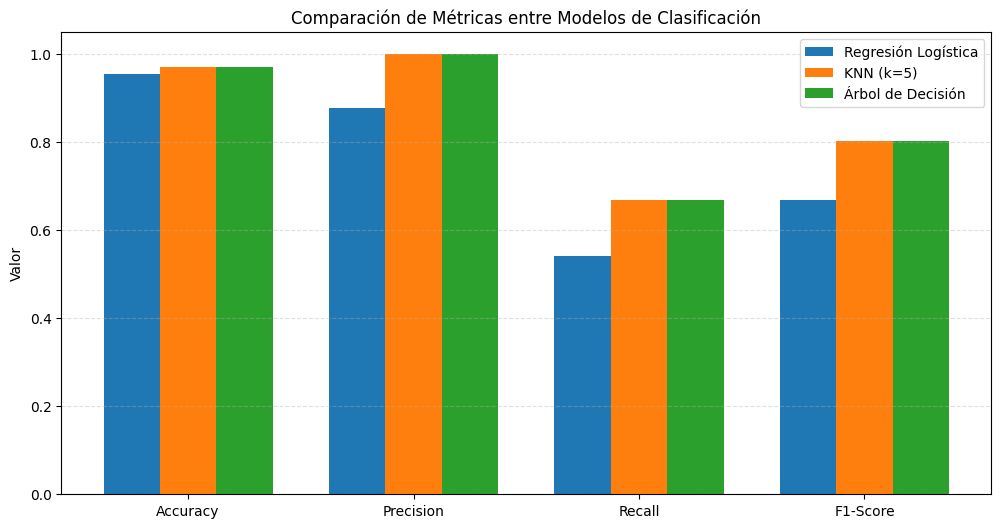

In [51]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

log_values  = tabla_metricas.loc["Regresión Logística"].values
knn_values  = tabla_metricas.loc["KNN"].values
tree_values = tabla_metricas.loc["Árbol de Decisión"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, log_values, width, label='Regresión Logística')
plt.bar(x, knn_values, width, label='KNN (k=5)')
plt.bar(x + width, tree_values, width, label='Árbol de Decisión')

plt.xticks(x, metrics)
plt.ylabel("Valor")
plt.title("Comparación de Métricas entre Modelos de Clasificación")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


## Contexto comercial

El presente proyecto se enmarca en un contexto sanitario, donde una institución de salud busca mejorar la detección temprana de pacientes con riesgo de desarrollar diabetes. La diabetes es una enfermedad crónica de alta prevalencia que, si no es diagnosticada y tratada a tiempo, puede derivar en complicaciones severas como enfermedades cardiovasculares, insuficiencia renal y daño neurológico.

En este escenario, la organización cuenta con información clínica básica de sus pacientes, como niveles de glucosa en sangre, hemoglobina glicosilada (HbA1c), edad y otros antecedentes médicos. El objetivo comercial consiste en utilizar estos datos para construir modelos analíticos que permitan identificar de manera temprana a pacientes con alta probabilidad de padecer diabetes, optimizando así la asignación de recursos médicos y priorizando la atención preventiva.

El uso de modelos de clasificación aporta valor al proceso de toma de decisiones clínicas, funcionando como una herramienta de apoyo para los profesionales de la salud, sin reemplazar el diagnóstico médico, pero contribuyendo a mejorar la eficiencia y efectividad del sistema.


## Conclusión final

A partir de la comparación de los modelos de clasificación entrenados (Regresión Logística, KNN y Árbol de Decisión), se evaluó su desempeño utilizando métricas estándar como accuracy, precision, recall y F1-score. Los resultados obtenidos muestran que la regresión logística presenta un desempeño competitivo y equilibrado en todas las métricas consideradas, destacándose especialmente por su estabilidad entre precisión y capacidad de detección de casos positivos.

Si bien otros modelos alcanzan valores similares en algunas métricas, la regresión logística ofrece un mejor balance general, evitando sobreajuste y manteniendo una correcta capacidad de generalización sobre el conjunto de prueba. En función de estos resultados y considerando la necesidad de interpretabilidad en un contexto clínico, se selecciona la regresión logística como el modelo más adecuado para el problema planteado.
